In [2]:
import gillespy2
import numpy as np
import os
import sys
import time
import matplotlib.pyplot as plt
import jsf as jsf
from GillespieDirectMethod import gillespie_direct_method
%matplotlib widget


In [3]:

class BirthDeathModel_GP2(gillespy2.Model):
    def __init__(self, X0=10, Y0=10, X_growth_rate=1, X_death_rate=0.5, x_catalyst=1, y_death=1, t_max=5):
        super().__init__(name="BirthDeathModel")
        
        # Parameters
        self.add_parameter(gillespy2.Parameter(name="x_birth", expression=X_growth_rate ))
        self.add_parameter(gillespy2.Parameter(name="x_death", expression=X_death_rate))
        self.add_parameter(gillespy2.Parameter(name="y_death", expression=y_death))
        self.add_parameter(gillespy2.Parameter(name="x_catalyst", expression=x_catalyst))
        
        # Species
        # self.add_species(gillespy2.Species(name="X", initial_value=x0, switch_min=switch_th, switch_tol=0.1))
        self.add_species(gillespy2.Species(name="X", initial_value=X0 , mode="dynamic"))
        self.add_species(gillespy2.Species(name="Y", initial_value=Y0,  mode="dynamic"))
        
        # Reactions
        self.add_reaction(gillespy2.Reaction(name="birth", reactants={'X': 1}, products={'X': 2}, rate=self.listOfParameters['x_birth']))
        self.add_reaction(gillespy2.Reaction(name="death", reactants={'X': 1}, products={}, rate=self.listOfParameters['x_death']))
        self.add_reaction(gillespy2.Reaction(name="catalyst", reactants={'X': 1, 'Y': 1}, products={'X': 2, 'Y': 1}, propensity_function="x_catalyst*X*Y"))
        self.add_reaction(gillespy2.Reaction(name="death_Y", reactants={'Y': 1}, products={}, rate=self.listOfParameters['y_death']))
        
        self.timespan(np.linspace(0, t_max, 1001))

def jsf_process(X0=10, Y0=10, X_growth_rate=1, X_death_rate=0.5, x_catalyst=1, y_death=1, t_max=5, switch_th=100):
    # Implement the JSF process
    # Define the Parameters

    # Define the stoichiometry
    reactant_matrix =[[1, 0],
                    [1, 0],
                    [1, 1],
                    [0, 1]]

    product_matrix = [[2, 0],
                    [0, 0],
                    [2, 1],
                    [0, 0]]

    # Define the rates
    rates = lambda x, t: [X_growth_rate  * x[0],
                        X_death_rate * x[0],
                        x_catalyst * x[0] * x[1],
                        y_death * x[1]]

    stoich = {
            "nu": [ [a - b for a, b in zip(r1, r2)]
                    for r1, r2 in zip(product_matrix, reactant_matrix) ],
            "DoDisc": [0, 0],
            "nuReactant": reactant_matrix,
            "nuProduct": product_matrix,
            }

    my_opts = {
                "EnforceDo": [0, 0],
                "dt": 0.0001,
                "SwitchingThreshold": [switch_th, switch_th],
                "SwitchingType": "default"
            }
    x0_v = [X0, Y0]

    sim_jsf = jsf.jsf(x0_v, rates, stoich, t_max, config=my_opts, method="operator-splitting")
    return sim_jsf

def jsf_generous_process(X0=10, Y0=10, X_growth_rate=1, X_death_rate=0.5, x_catalyst=1, y_death=1, t_max=5, switch_th=100):
    # Implement the JSF process
    # Define the Parameters

    # Define the stoichiometry
    reactant_matrix =[[1, 0],
                    [1, 0],
                    [1, 1],
                    [0, 1]]

    product_matrix = [[2, 0],
                    [0, 0],
                    [2, 1],
                    [0, 0]]

    # Define the rates
    rates = lambda x, t: [X_growth_rate  * x[0],
                        X_death_rate * x[0],
                        x_catalyst * x[0] * x[1],
                        y_death * x[1]]

    stoich = {
            "nu": [ [a - b for a, b in zip(r1, r2)]
                    for r1, r2 in zip(product_matrix, reactant_matrix) ],
            "DoDisc": [0, 0],
            "nuReactant": reactant_matrix,
            "nuProduct": product_matrix,
            }

    my_opts = {
                "EnforceDo": [0, 0],
                "dt": 0.0001,
                "SwitchingThreshold": [switch_th, switch_th],
                "SwitchingType": "generous"
            }
    x0_v = [X0, Y0]

    sim_jsf = jsf.jsf(x0_v, rates, stoich, t_max, config=my_opts, method="operator-splitting")
    return sim_jsf


In [4]:
# X0=10
# Y0=10
# X_growth_rate =10
# X_death_rate  =800
# x_catalyst    =100
# y_death       =1

# t_max= 1
# numb_of_traj= 10

X0=10
Y0=1000
X_growth_rate=10
X_death_rate=50
x_catalyst=1
y_death=100

t_max= 0.275
numb_of_traj= 100

model = BirthDeathModel_GP2(X0, Y0, X_growth_rate, X_death_rate, x_catalyst, y_death, t_max=t_max)


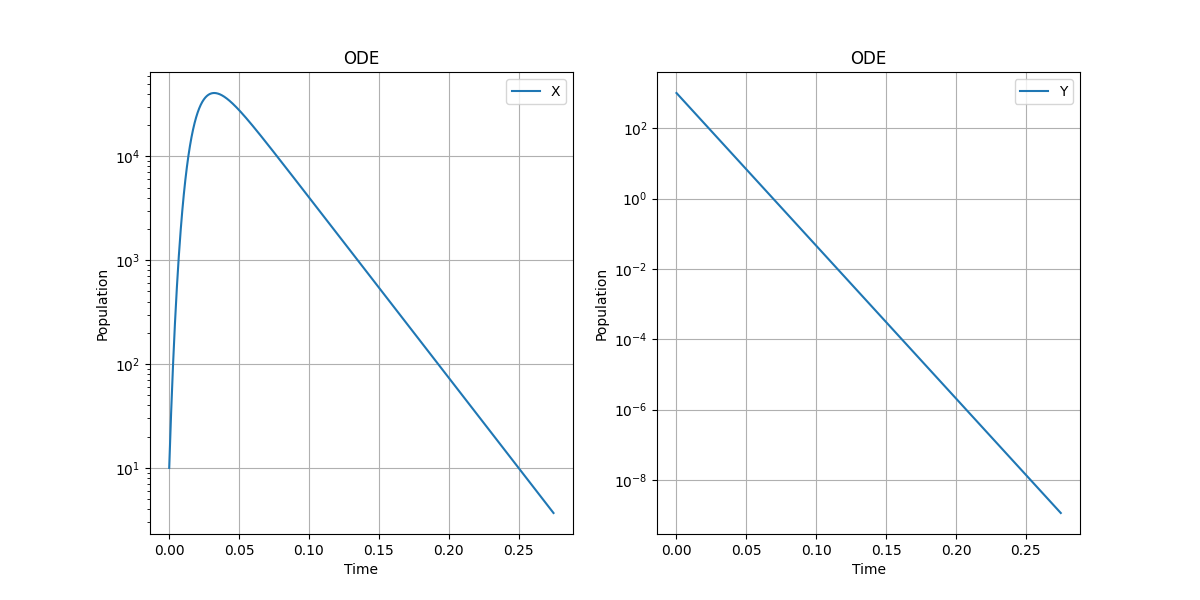

In [5]:


model = BirthDeathModel_GP2(X0, Y0, X_growth_rate, X_death_rate, x_catalyst, y_death, t_max=t_max)

# ODE
results_ode = model.run(algorithm="ODE")

# plot the ode results with each species in a different subplot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(results_ode[0]['time'], results_ode[0]['X'], label='X')
ax[1].plot(results_ode[0]['time'], results_ode[0]['Y'], label='Y')
for i in range(2):
    ax[i].set_title('ODE')
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('Population')
    ax[i].legend()
    ax[i].grid()
    ax[i].set_yscale('log')
# plt.tight_layout()

# ax[0].set_ylim([1, 1e5])
plt.show()



In [44]:
# Gillespy2
start_time = time.perf_counter()
results_gil = model.run(algorithm="SSA", number_of_trajectories=numb_of_traj)
end_time = time.perf_counter()
gil_elapsed_time_total = end_time - start_time
gil_elapsed_time_traj = gil_elapsed_time_total / numb_of_traj
print(f"Elapsed time for Gillespy2: {gil_elapsed_time_total:0.4f} seconds")
print(f"Elapsed time per trajectory for Gillespy2: {gil_elapsed_time_traj:0.4f} seconds")


Elapsed time for Gillespy2: 27.3438 seconds
Elapsed time per trajectory for Gillespy2: 0.0273 seconds


In [6]:
c_solver = gillespy2.TauHybridCSolver(model=model)
start_time = time.perf_counter()
results_gp2 = model.run(solver=c_solver, number_of_trajectories=100)
end_time = time.perf_counter()
gp2_elapsed_time_total = end_time - start_time
gp2_elapsed_time_traj = gp2_elapsed_time_total / 100

print(f"Elapsed time for C Solver: {gp2_elapsed_time_total:0.4f} seconds")
print(f"Elapsed time per trajectory for for C Solver: {gp2_elapsed_time_traj:0.4f} seconds")

python_solver = gillespy2.TauHybridSolver(model=model)
start_time = time.perf_counter()
results_gp2 = model.run(solver=python_solver, number_of_trajectories=100)
end_time = time.perf_counter()
gp2_elapsed_time_total = end_time - start_time
gp2_elapsed_time_traj = gp2_elapsed_time_total / 100

print(f"Elapsed time for Python Solver: {gp2_elapsed_time_total:0.4f} seconds")
print(f"Elapsed time per trajectory for Python Solver: {gp2_elapsed_time_traj:0.4f} seconds")




Elapsed time for C Solver: 22.0336 seconds
Elapsed time per trajectory for for C Solver: 0.2203 seconds
Elapsed time for Python Solver: 131.6238 seconds
Elapsed time per trajectory for Python Solver: 1.3162 seconds


In [23]:
# Gillespy2
start_time = time.perf_counter()
results_gp2 = model.run(algorithm="Tau-Hybrid", number_of_trajectories=numb_of_traj)
end_time = time.perf_counter()
gp2_elapsed_time_total = end_time - start_time
gp2_elapsed_time_traj = gp2_elapsed_time_total / numb_of_traj
print(f"Elapsed time for Gillespy2: {gp2_elapsed_time_total:0.4f} seconds")
print(f"Elapsed time per trajectory for Gillespy2: {gp2_elapsed_time_traj:0.4f} seconds")


Elapsed time for Gillespy2: 250.1326 seconds
Elapsed time per trajectory for Gillespy2: 0.2501 seconds


In [100]:

# JSF
# store the results
results_jsf = []

progress = 0
start_time = time.perf_counter()
for i in range(numb_of_traj):
    sim_jsf = jsf_process(X0, Y0, X_growth_rate, X_death_rate, x_catalyst, y_death, t_max=t_max, switch_th=500)
    results_jsf.append(sim_jsf)
    
    progress = (progress + 1)
    prog = round(progress / numb_of_traj * 100)
    print("|" + "-" * prog + " " * (100 - prog) + f"| {prog:.2f}%", end="\r") 
end_time = time.perf_counter()
jsf_elapsed_time_total = end_time - start_time
jsf_elapsed_time_traj = jsf_elapsed_time_total / numb_of_traj

print('\n')
print(f"Elapsed time for JSF: {jsf_elapsed_time_total:0.4f} seconds")
print(f"Elapsed time per trajectory for JSF: {jsf_elapsed_time_traj:0.4f} seconds")

results_generous_jsf = []
progress = 0
start_time = time.perf_counter()
for i in range(numb_of_traj):
    sim_jsf = jsf_generous_process(X0, Y0, X_growth_rate, X_death_rate, x_catalyst, y_death, t_max=t_max, switch_th=0)
    results_generous_jsf.append(sim_jsf)
    
    progress = (progress + 1)
    prog = round(progress / numb_of_traj * 100)
    print("|" + "-" * prog + " " * (100 - prog) + f"| {prog:.2f}%", end="\r")
end_time = time.perf_counter()
gen_jsf_elapsed_time_total = end_time - start_time
gen_jsf_elapsed_time_traj = gen_jsf_elapsed_time_total / numb_of_traj

print('\n')
print(f"Elapsed time for JSF: {gen_jsf_elapsed_time_total:0.4f} seconds")
print(f"Elapsed time per trajectory for JSF: {gen_jsf_elapsed_time_traj:0.4f} seconds")




|----------------------------------------------------------------------------------------------------| 100.00%

Elapsed time for JSF: 34.5458 seconds
Elapsed time per trajectory for JSF: 0.3455 seconds
|----------------------------------------------------------------------------------------------------| 100.00%

Elapsed time for JSF: 2.2029 seconds
Elapsed time per trajectory for JSF: 0.0220 seconds


In [102]:
def log_mean(data):
    data = np.array(data)
    # data[data == 0] = np.nan  # Replace zeros with NaN to avoid log(0)
    log_data = np.log(data)
    log_data[log_data == -np.inf] = 0  # Replace -inf with NaN
    mean_log = np.nanmean(log_data, axis=0)  # Compute mean ignoring NaNs
    return np.exp(mean_log)

# interpolate the results onto a common time grid
t_common = np.linspace(0, t_max, 1001)
# store the results
results_jsf_interp = []
for sim_jsf in results_jsf:
    results_jsf_interp.append([np.interp(t_common, sim_jsf[1], sim_jsf[0][0]), np.interp(t_common, sim_jsf[1], sim_jsf[0][1])])

results_generous_jsf_interp = []
for sim_jsf in results_generous_jsf:
    results_generous_jsf_interp.append([np.interp(t_common, sim_jsf[1], sim_jsf[0][0]), np.interp(t_common, sim_jsf[1], sim_jsf[0][1])])



# mean_jsf = np.exp(np.mean(np.log(results_jsf_interp), axis=0))
# Calculate the log mean, accounting for zero values
# mean_jsf = log_mean(results_jsf_interp)
# mean_jsf = np.mean(results_jsf_interp, axis=0)
mean_jsf = np.median(results_jsf_interp, axis=0)

# mean_generous_jsf = np.exp(np.mean(np.log(results_generous_jsf_interp), axis=0))
# Calculate the log mean, accounting for zero values
# mean_generous_jsf = log_mean(results_generous_jsf_interp)
# mean_generous_jsf = np.mean(results_generous_jsf_interp, axis=0)
mean_generous_jsf = np.median(results_generous_jsf_interp, axis=0)

# # do the same for gp2
results_gp2_interp = []
for traj in results_gp2:
    results_gp2_interp.append([np.interp(t_common, traj['time'], traj['X']), np.interp(t_common, traj['time'], traj['Y'])])

# compute the mean using the interpolated results
# mean_gp2 = np.exp(np.mean(np.log(results_gp2_interp), axis=0))
# mean_gp2 = log_mean(results_gp2_interp)
# mean_gp2 = np.mean(results_gp2_interp, axis=0)
mean_gp2 = np.median(results_gp2_interp, axis=0)

# do the same for SSA
results_gil_interp = []
for traj in results_gil:
    results_gil_interp.append([np.interp(t_common, traj['time'], traj['X']), np.interp(t_common, traj['time'], traj['Y'])])

# compute the mean using the interpolated results
# mean_gil = np.exp(np.mean(np.log(results_gil_interp), axis=0))
# mean_gil = log_mean(results_gil_interp)
# mean_gil = np.mean(results_gil_interp, axis=0)
mean_gil = np.median(results_gil_interp, axis=0)



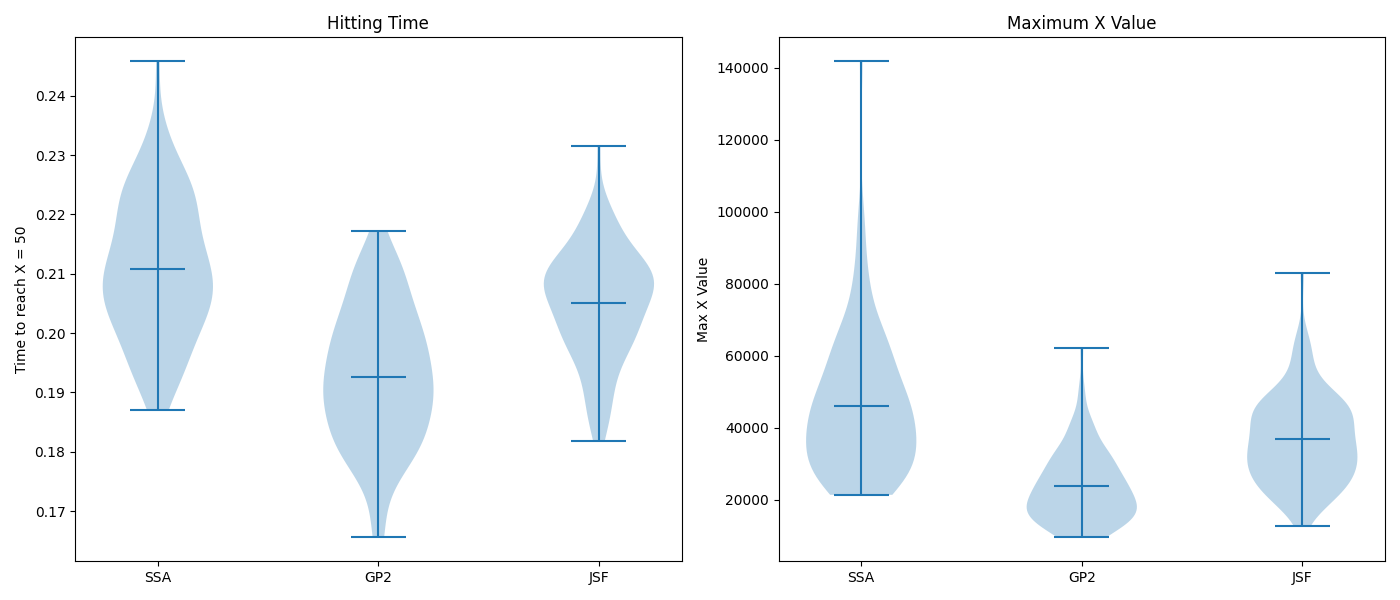

In [103]:
# compute the time for each trajectory to reach a certain value, X = 10
def time_to_reach(t_common, results, numb_of_traj, hitting_value=10):
    time_to_reach = []
    for i in range(numb_of_traj):
        x_p = 0
        for t, x in zip(t_common, results[i][0]):
            if x <= hitting_value and x_p >= hitting_value:
                time_to_reach.append(t)
                break
            x_p = x
    return time_to_reach

# compute the max X value for each trajectory
def max_x(t_common, results, numb_of_traj):
    max_x = []
    for i in range(numb_of_traj):
        max_x.append(np.max(results[i][0]))
    return max_x

# Hitting time
# SSA
time_to_reach_gil = time_to_reach(t_common, results_gil_interp, numb_of_traj, hitting_value=50)
# GP2
time_to_reach_gp2 = time_to_reach(t_common, results_gp2_interp, numb_of_traj, hitting_value=50)
# JSF
time_to_reach_jsf = time_to_reach(t_common, results_jsf_interp, numb_of_traj, hitting_value=50)

# Max X
# SSA
max_x_gil = max_x(t_common, results_gil_interp, numb_of_traj)
# GP2
max_x_gp2 = max_x(t_common, results_gp2_interp, numb_of_traj)
# JSF
max_x_jsf = max_x(t_common, results_jsf_interp, numb_of_traj)



# create a subplot to plot the hitting time and max X value using violin plots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Hitting time violin plot
ax[0].violinplot([time_to_reach_gil, time_to_reach_gp2, time_to_reach_jsf], showmeans=True)
ax[0].set_xticks([1, 2, 3])
ax[0].set_xticklabels(['SSA', 'GP2', 'JSF'])
ax[0].set_ylabel('Time to reach X = 50')
ax[0].set_title('Hitting Time')

# Max X value violin plot
ax[1].violinplot([max_x_gil, max_x_gp2, max_x_jsf], showmeans=True)
ax[1].set_xticks([1, 2, 3])
ax[1].set_xticklabels(['SSA', 'GP2', 'JSF'])
ax[1].set_ylabel('Max X Value')
ax[1].set_title('Maximum X Value')

plt.tight_layout()
plt.show()


<>:66: SyntaxWarning: invalid escape sequence '\O'
<>:74: SyntaxWarning: invalid escape sequence '\O'
<>:93: SyntaxWarning: invalid escape sequence '\O'
<>:101: SyntaxWarning: invalid escape sequence '\O'
<>:66: SyntaxWarning: invalid escape sequence '\O'
<>:74: SyntaxWarning: invalid escape sequence '\O'
<>:93: SyntaxWarning: invalid escape sequence '\O'
<>:101: SyntaxWarning: invalid escape sequence '\O'
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/331838034.py:66: SyntaxWarning: invalid escape sequence '\O'
  ax[1, 0].set_title('JSF: $\Omega = 10^2$')
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/331838034.py:74: SyntaxWarning: invalid escape sequence '\O'
  ax[1, 1].set_title('JSF: $\Omega = 10^2$')
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/331838034.py:93: SyntaxWarning: invalid escape sequence '\O'
  ax[2, 0].set_title('JSF: $\Omega = 10^3$')
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/331838034.py

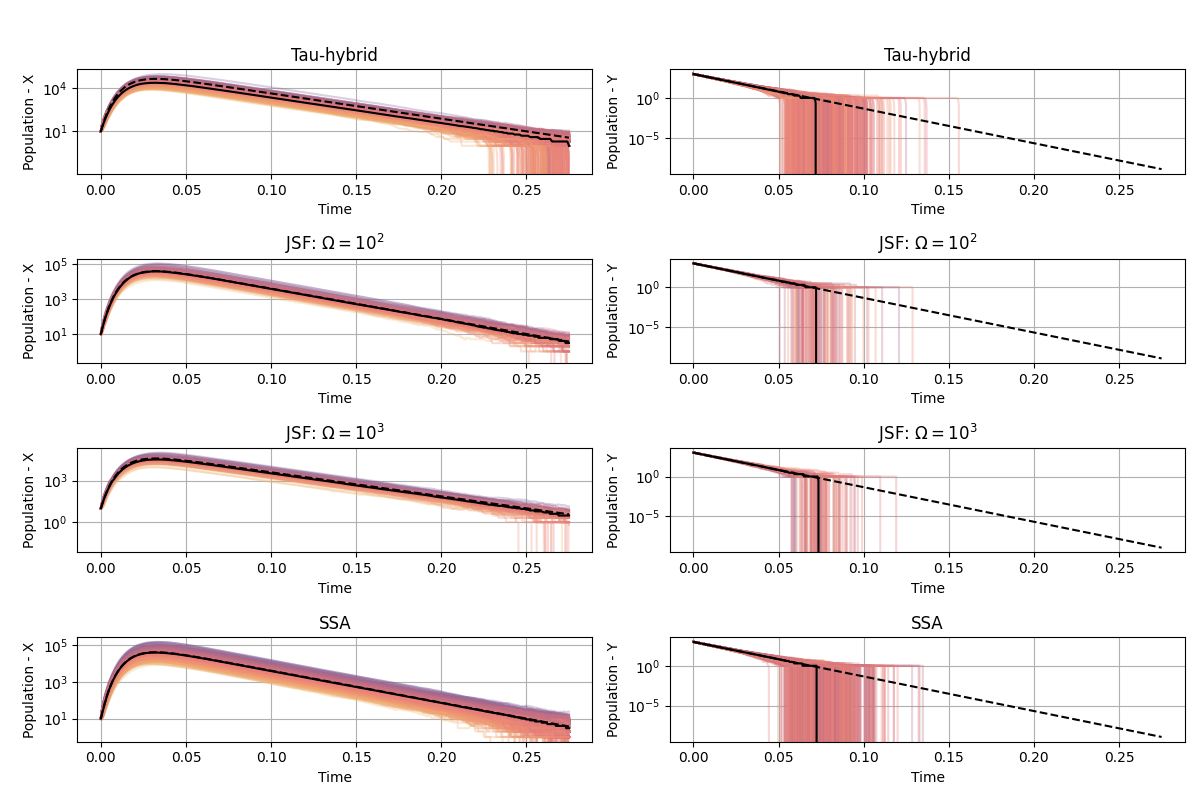

In [95]:
from matplotlib.colors import LinearSegmentedColormap

alpha_val = 0.3

# Determine the color based on the maximum value of each trajectory
max_values_gp2 = [np.max(np.log(traj[0])) for traj in results_gp2_interp]
max_values_jsf = [np.max(np.log(traj[0])) for traj in results_jsf_interp]
max_values_generous_jsf = [np.max(np.log(traj[0])) for traj in results_generous_jsf_interp]
max_vales_gil = [np.max(np.log(traj[0])) for traj in results_gil_interp]

# Normalize the maximum values to the range [0, 1] for color mapping
norm_gp2 = plt.Normalize(min(max_values_gp2), max(max_values_gp2))
norm_jsf = plt.Normalize(min(max_values_jsf), max(max_values_jsf))
norm_generous_jsf = plt.Normalize(min(max_values_generous_jsf), max(max_values_generous_jsf))
norm_gil = plt.Normalize(min(max_vales_gil), max(max_vales_gil))

# Create a color map
# Define the color gradient
jsf_color = (131/255, 96/255, 150/255)
gp2_color = (237/255, 123/255, 123/255)
gil_color = (240/255, 184/255, 110/255)
colors = [gil_color, gp2_color, jsf_color]
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# plot the results
fig, ax = plt.subplots(4, 2, figsize=(12, 8))

for idx, traj in enumerate(results_gp2_interp):
    color_gp2 = cmap(norm_gp2(max_values_gp2[idx]))
    ax[0, 0].plot(t_common, traj[0], color=color_gp2, label=f'Gillespy2 {idx+1}', alpha=alpha_val)
    ax[0, 1].plot(t_common, traj[1], color=color_gp2, label=f'Gillespy2 {idx+1}', alpha=alpha_val)
ax[0, 0].plot(t_common, mean_gp2[0], 'k-', label='Mean')
ax[0, 1].plot(t_common, mean_gp2[1], 'k-', label='Mean')

ax[0, 0].plot(results_ode['time'], results_ode['X'], 'k--', label='Analytic')
ax[0, 1].plot(results_ode['time'], results_ode['Y'], 'k--', label='Analytic')

ax[0, 0].set_title('Tau-hybrid')
ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Population - X')
ax[0, 0].set_yscale('log')
# ax[0, 0].set_ylim(1, 10**7.2)
# ax[0, 0].set_xlim(0, 0.5)
ax[0, 0].grid()

ax[0, 1].set_title('Tau-hybrid')
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('Population - Y')
ax[0, 1].set_yscale('log')
# ax[0, 1].set_ylim(1, 6)
# ax[0, 1].set_xlim(0, 0.5)
ax[0, 1].grid()

for idx, sim_jsf in enumerate(results_jsf_interp):
    color_jsf = cmap(norm_jsf(max_values_jsf[idx]))
    ax[1, 0].plot(t_common, sim_jsf[0], color=color_jsf, label=f'JSF {idx+1}', alpha=alpha_val)
    ax[1, 1].plot(t_common, sim_jsf[1], color=color_jsf, label=f'JSF {idx+1}', alpha=alpha_val)


ax[1, 0].plot(t_common, mean_jsf[0], 'k-', label='Mean')
ax[1, 1].plot(t_common, mean_jsf[1], 'k-', label='Mean')

ax[1, 0].plot(results_ode['time'], results_ode['X'], 'k--', label='Analytic')
ax[1, 1].plot(results_ode['time'], results_ode['Y'], 'k--', label='Analytic')

ax[1, 0].set_title('JSF: $\Omega = 10^2$')
ax[1, 0].set_xlabel('Time')
ax[1, 0].set_ylabel('Population - X')
ax[1, 0].set_yscale('log')
# ax[1, 0].set_ylim(1, 10**7.2)
# ax[1, 0].set_xlim(0, 0.5)
ax[1, 0].grid()

ax[1, 1].set_title('JSF: $\Omega = 10^2$')
ax[1, 1].set_xlabel('Time')
ax[1, 1].set_ylabel('Population - Y')
ax[1, 1].set_yscale('log')
# ax[1, 1].set_ylim(1, 6)
# ax[1, 1].set_xlim(0, 0.5)
ax[1, 1].grid()

for idx, sim_jsf in enumerate(results_generous_jsf_interp):
    color_jsf = cmap(norm_generous_jsf(max_values_generous_jsf[idx]))
    ax[2, 0].plot(t_common, sim_jsf[0], color=color_jsf, label=f'JSF {idx+1}', alpha=alpha_val)
    ax[2, 1].plot(t_common, sim_jsf[1], color=color_jsf, label=f'JSF {idx+1}', alpha=alpha_val)

ax[2, 0].plot(t_common, mean_generous_jsf[0], 'k-', label='Mean')
ax[2, 1].plot(t_common, mean_generous_jsf[1], 'k-', label='Mean')

ax[2, 0].plot(results_ode['time'], results_ode['X'], 'k--', label='Analytic')
ax[2, 1].plot(results_ode['time'], results_ode['Y'], 'k--', label='Analytic')

ax[2, 0].set_title('JSF: $\Omega = 10^3$')
ax[2, 0].set_xlabel('Time')
ax[2, 0].set_ylabel('Population - X')
ax[2, 0].set_yscale('log')
# ax[2, 0].set_ylim(1, 10**7.2)
# ax[2, 0].set_xlim(0, 0.5)
ax[2, 0].grid()

ax[2, 1].set_title('JSF: $\Omega = 10^3$')
ax[2, 1].set_xlabel('Time')
ax[2, 1].set_ylabel('Population - Y')
ax[2, 1].set_yscale('log')
# ax[2, 1].set_ylim(1, 6)
# ax[2, 1].set_xlim(0, 0.5)
ax[2, 1].grid()

for idx, traj in enumerate(results_gil_interp):
    color_gil = cmap(norm_gil(max_vales_gil[idx]))
    ax[3, 0].plot(t_common, traj[0], color=color_gil, label=f'Gillespy2 {idx+1}', alpha=alpha_val)
    ax[3, 1].plot(t_common, traj[1], color=color_gil, label=f'Gillespy2 {idx+1}', alpha=alpha_val)
ax[3, 0].plot(t_common, mean_gil[0], 'k-', label='Mean')
ax[3, 1].plot(t_common, mean_gil[1], 'k-', label='Mean')

ax[3, 0].plot(results_ode['time'], results_ode['X'], 'k--', label='Analytic')
ax[3, 1].plot(results_ode['time'], results_ode['Y'], 'k--', label='Analytic')   

ax[3, 0].set_title('SSA')
ax[3, 0].set_xlabel('Time')
ax[3, 0].set_ylabel('Population - X')
ax[3, 0].set_yscale('log')
# ax[3, 0].set_ylim(1, 10**7.2)
# ax[3, 0].set_xlim(0, 0.5)
ax[3, 0].grid()

ax[3, 1].set_title('SSA')
ax[3, 1].set_xlabel('Time')
ax[3, 1].set_ylabel('Population - Y')
ax[3, 1].set_yscale('log')
# ax[3, 1].set_ylim(1, 6)
# ax[3, 1].set_xlim(0, 0.5)
ax[3, 1].grid()


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# plt.savefig('AutocatalystTrajectores.pdf')

/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/552036531.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 2, figsize=(14, 10))


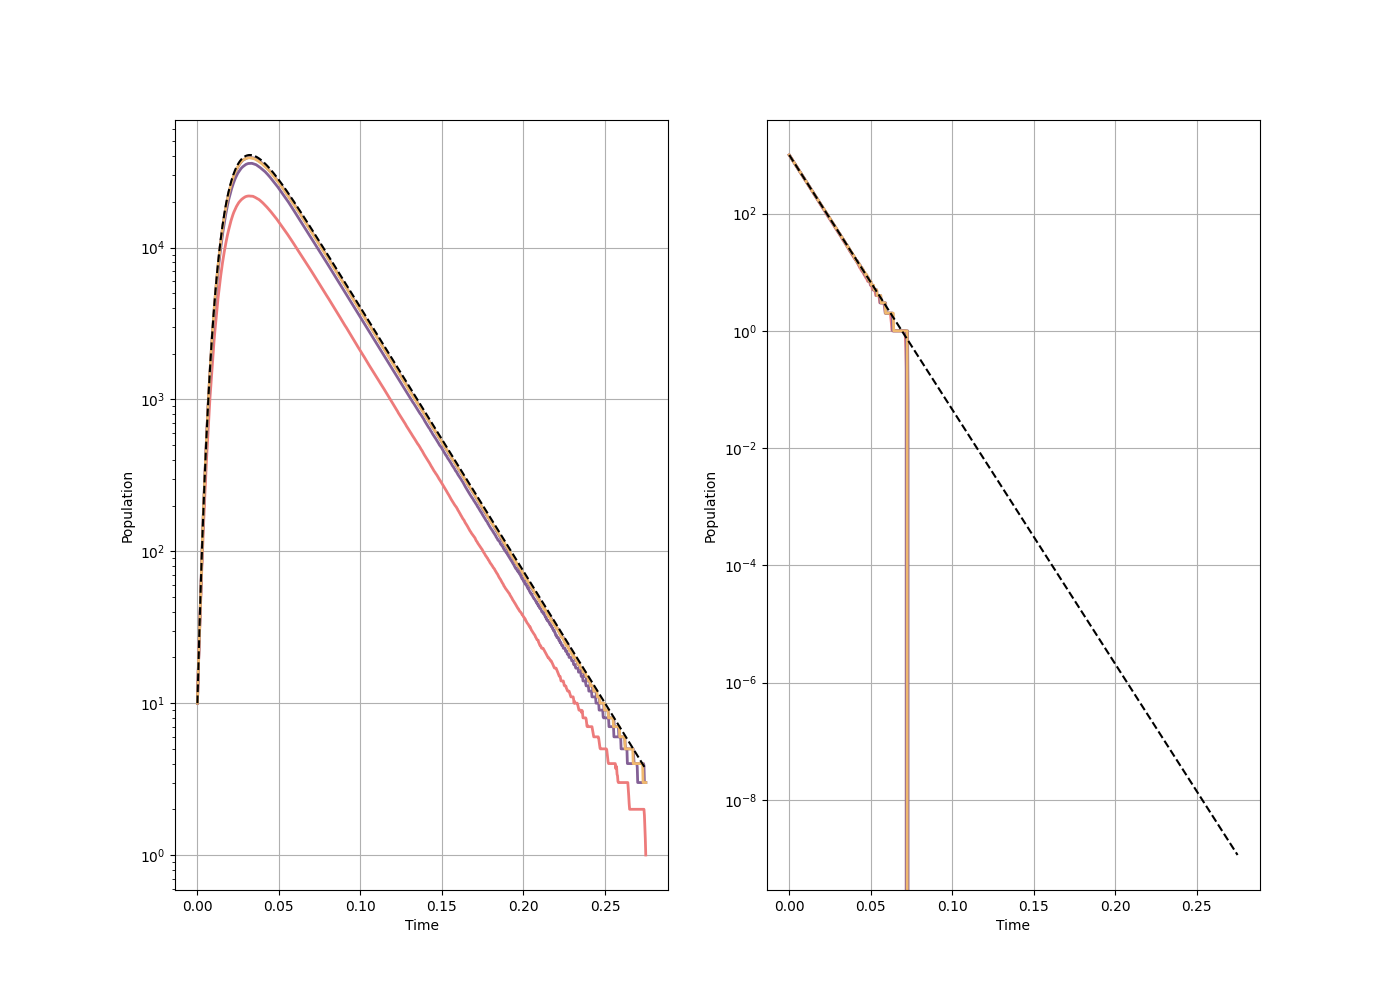

In [48]:
from matplotlib.colors import LinearSegmentedColormap

alpha_val = 0.25

# Create a color map
# Define the color gradient
jsf_color = (131/255, 96/255, 150/255)
gp2_color = (237/255, 123/255, 123/255)
gil_color = (240/255, 184/255, 110/255)

# plot the results
fig, ax = plt.subplots(1, 2, figsize=(14, 10))


ax[0].plot(t_common, mean_gp2[0], '-', label='Mean', color=gp2_color, linewidth=2)
ax[0].plot(t_common, mean_jsf[0], '-', label='Mean', color=jsf_color, linewidth=2)
ax[0].plot(t_common, mean_generous_jsf[0], '-', label='Mean', color=jsf_color, linewidth=2)
ax[0].plot(t_common, mean_gil[0], '-', label='Mean', color=gil_color, linewidth=2)

ax[0].plot(results_ode['time'], results_ode['X'], 'k--', label='Analytic')

ax[1].plot(t_common, mean_gp2[1], '-', label='Mean', color=gp2_color, linewidth=2)
ax[1].plot(t_common, mean_jsf[1], '-', label='Mean', color=jsf_color, linewidth=2)
ax[1].plot(t_common, mean_generous_jsf[1], '-', label='Mean', color=jsf_color, linewidth=2)
ax[1].plot(t_common, mean_gil[1], '-', label='Mean', color=gil_color, linewidth=2)

ax[1].plot(results_ode['time'], results_ode['Y'], 'k--', label='Analytic')

ax[0].set_xlabel('Time')
ax[0].set_ylabel('Population')
ax[0].set_yscale('log')
# ax[0].set_ylim(0.9, pow(10,2.5))
ax[0].grid()

ax[1].set_xlabel('Time')
ax[1].set_ylabel('Population')
ax[1].set_yscale('log')
# ax[1].set_ylim(1, 10)
ax[1].grid()

plt.show()

In [40]:
len(results_ode['X']) 

276

<>:47: SyntaxWarning: invalid escape sequence '\O'
<>:52: SyntaxWarning: invalid escape sequence '\O'
<>:47: SyntaxWarning: invalid escape sequence '\O'
<>:52: SyntaxWarning: invalid escape sequence '\O'
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/976759339.py:47: SyntaxWarning: invalid escape sequence '\O'
  ax[0].plot(t_common, error_jsf_X, '-', label='JSF: $\Omega=10^2$', color=jsf_color, linewidth=lnwdth)
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/976759339.py:52: SyntaxWarning: invalid escape sequence '\O'
  ax[1].plot(t_common, error_jsf_to_gil_X, '-', label='JSF: $\Omega=10^2$', color=jsf_color, linewidth=lnwdth)
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/976759339.py:26: RuntimeWarning: invalid value encountered in scalar divide
  error_gp2_to_gil_Y = [abs(a - b)/a for a, b in zip(mean_gil[1], mean_gp2[1])]
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/976759339.py:28: RuntimeWarning: divide by 

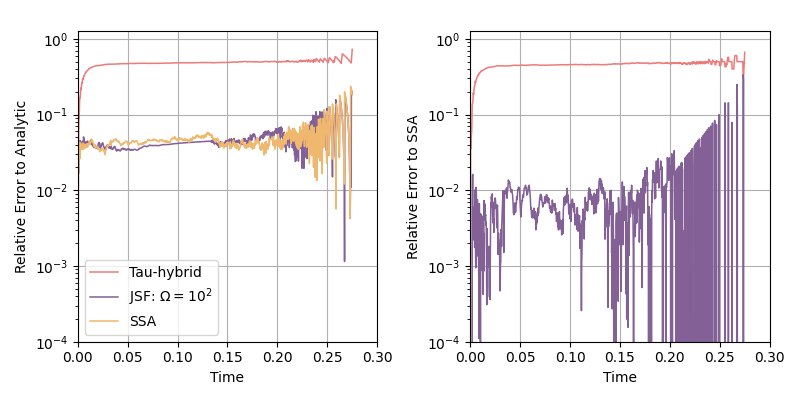

In [51]:
blue_color = (106/255, 123/255, 237/255)
# calculate the mean squared error

# error_gil_X = np.abs(results_ode['X'] - mean_gil[0])/results_ode['X']
# error_gil_Y = np.abs(results_ode['Y'] - mean_gil[1])/results_ode['Y']

# error_gp2_X = np.abs(results_ode['X'] - mean_gp2[0])/results_ode['X']
# error_gp2_Y = np.abs(results_ode['Y'] - mean_gp2[1])/results_ode['Y']

# error_jsf_X = np.abs(results_ode['X'] - mean_jsf[0])/results_ode['X']
# error_jsf_Y = np.abs(results_ode['Y'] - mean_jsf[1])/results_ode['Y']

# error_generous_jsf_X = np.abs(results_ode['X'] - mean_generous_jsf[0])/results_ode['X']
# error_generous_jsf_Y = np.abs(results_ode['Y'] - mean_generous_jsf[1])/results_ode['Y']

error_gil_X = [abs(a - b)/a for a, b in zip(results_ode['X'], mean_gil[0])]
error_gil_Y = [abs(a - b)/a for a, b in zip(results_ode['Y'], mean_gil[1])]
error_gp2_X = [abs(a - b)/a for a, b in zip(results_ode['X'], mean_gp2[0])]
error_gp2_Y = [abs(a - b)/a for a, b in zip(results_ode['Y'], mean_gp2[1])]
error_jsf_X = [abs(a - b)/a for a, b in zip(results_ode['X'], mean_jsf[0])]
error_jsf_Y = [abs(a - b)/a for a, b in zip(results_ode['Y'], mean_jsf[1])]
error_generous_jsf_X = [abs(a - b)/a for a, b in zip(results_ode['X'], mean_generous_jsf[0])]
error_generous_jsf_Y = [abs(a - b)/a for a, b in zip(results_ode['Y'], mean_generous_jsf[1])]

error_gp2_to_gil_X = [abs(a - b)/a for a, b in zip(mean_gil[0], mean_gp2[0])]
error_gp2_to_gil_Y = [abs(a - b)/a for a, b in zip(mean_gil[1], mean_gp2[1])]
error_jsf_to_gil_X = [abs(a - b)/a for a, b in zip(mean_gil[0], mean_jsf[0])]
error_jsf_to_gil_Y = [abs(a - b)/a for a, b in zip(mean_gil[1], mean_jsf[1])]
error_generous_jsf_to_gil_X = [abs(a - b)/a for a, b in zip(mean_gil[0], mean_generous_jsf[0])]
error_generous_jsf_to_gil_Y = [abs(a - b)/a for a, b in zip(mean_gil[1], mean_generous_jsf[1])]

# error_gp2_X = np.linalg.norm(mean_gp2 - results_ode['X'], ord=2, axis=0)
# error_jsf_X = np.linalg.norm(mean_jsf - results_ode['X'], ord=2, axis=0)
# error_generous_jsf_X = np.linalg.norm(mean_generous_jsf - results_ode['X'], ord=2, axis=0)
# error_gil_X = np.linalg.norm(mean_gil - results_ode['X'], ord=2, axis=0)

# error_gp2_Y = np.linalg.norm(mean_gp2 - results_ode['Y'], ord=2, axis=0)
# error_jsf_Y = np.linalg.norm(mean_jsf - results_ode['Y'], ord=2, axis=0)
# error_generous_jsf_Y = np.linalg.norm(mean_generous_jsf - results_ode['Y'], ord=2, axis=0)
# error_gil_Y = np.linalg.norm(mean_gil - results_ode['Y'], ord=2, axis=0)

# plot the results
lnwdth = 1.1
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(t_common, error_gp2_X, '-', label='Tau-hybrid', color=gp2_color, linewidth=lnwdth)
ax[0].plot(t_common, error_jsf_X, '-', label='JSF: $\Omega=10^2$', color=jsf_color, linewidth=lnwdth)
# ax[0].plot(t_common, error_generous_jsf_X, '-', label='JSF (Generous switching): ', color=blue_color, linewidth=lnwdth)
ax[0].plot(t_common, error_gil_X, '-', label='SSA', color=gil_color, linewidth=lnwdth)

ax[1].plot(t_common, error_gp2_to_gil_X, '-', label='Tau-hybrid', color=gp2_color, linewidth=lnwdth)
ax[1].plot(t_common, error_jsf_to_gil_X, '-', label='JSF: $\Omega=10^2$', color=jsf_color, linewidth=lnwdth)
# ax[1].plot(t_common, error_generous_jsf_to_gil_X, '-', label='Mean', color=blue_color, linewidth=lnwdth)

ax[0].set_xlabel('Time')
ax[0].set_ylabel('Relative Error to Analytic')
ax[0].set_yscale('log')
ax[0].set_ylim(pow(10,-4), pow(10,0.1))
ax[0].set_xlim(0, 0.3)
ax[0].grid()

ax[1].set_xlabel('Time')
ax[1].set_ylabel('Relative Error to SSA')
ax[1].set_yscale('log')
ax[1].set_ylim(pow(10,-4), pow(10,0.1))
ax[1].set_xlim(0, 0.3)
ax[1].grid()

ax[0].legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

plt.savefig('AutocatalystErrors.pdf')

<>:34: SyntaxWarning: invalid escape sequence '\O'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\O'
<>:74: SyntaxWarning: invalid escape sequence '\O'
<>:34: SyntaxWarning: invalid escape sequence '\O'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\O'
<>:74: SyntaxWarning: invalid escape sequence '\O'
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_55090/2749522603.py:34: SyntaxWarning: invalid escape sequence '\O'
  ax[0].set_xticklabels(['JSF: $\Omega = 10^2$', 'Tau-Hybrid'])
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_55090/2749522603.py:35: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel('Maximum X Population - $\log_{10}(X)$')
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_55090/2749522603.py:62: SyntaxWarning: invalid escape sequence '\O'
  ax[1].set_xticklabels(['JSF: $\Omega = 10^2$', 'Tau-Hybrid'])
/var/folders/w6/dtzmmv8

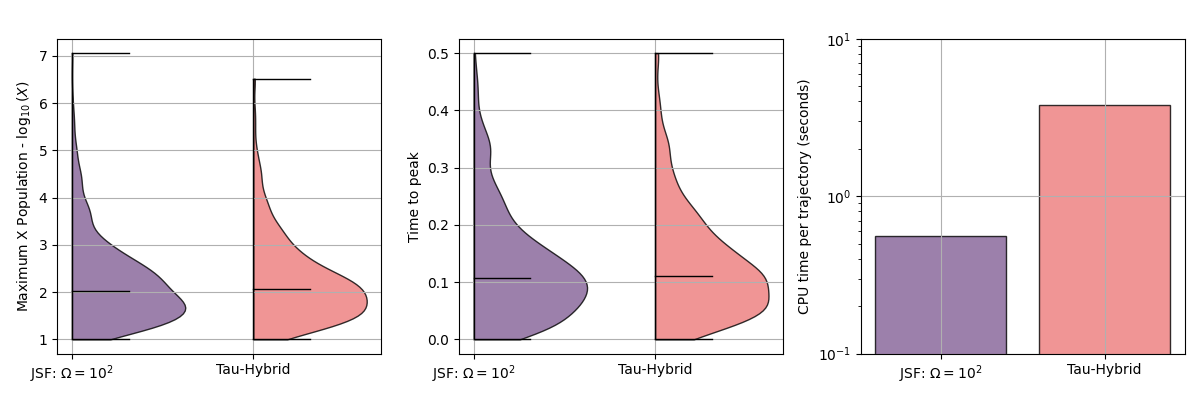

In [ ]:
alpha_val = 0.8

max_values_gp2 = np.log10([np.max((traj[0])) for traj in results_gp2_interp])
max_values_jsf = np.log10([np.max((traj[0])) for traj in results_jsf_interp])

# compute the time to the peak value
peak_time_gp2 = [t_common[np.argmax(traj[0])] for traj in results_gp2_interp]
peak_time_jsf = [t_common[np.argmax(traj[0])] for traj in results_jsf_interp]

# determine the distribution of the maximum values
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

data = [max_values_jsf, max_values_gp2]
positions = [1, 2]
colors = [jsf_color, gp2_color]

violin_parts = ax[0].violinplot(data, positions=positions, showextrema=True, showmedians=True, side='high', widths=1.25)

# Set the colors for the violins
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor(colors[i])
    pc.set_alpha(alpha_val)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Customize the other parts of the violin plot
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    vp = violin_parts[partname]
    vp.set_edgecolor('black')
    vp.set_linewidth(1)

ax[0].set_xticks(positions)
ax[0].set_xticklabels(['JSF: $\Omega = 10^2$', 'Tau-Hybrid'])
ax[0].set_ylabel('Maximum X Population - $\log_{10}(X)$')
ax[0].grid()


# Combine the two histograms onto one plot
# Combine the two distributions into violin plots
data = [peak_time_jsf, peak_time_gp2]
positions = [1, 2]
colors = [jsf_color, gp2_color]

violin_parts = ax[1].violinplot(data, positions=positions, showextrema=True, showmedians=True, side='high', widths=1.25)

# Set the colors for the violins
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor(colors[i])
    pc.set_alpha(alpha_val)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Customize the other parts of the violin plot
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    vp = violin_parts[partname]
    vp.set_edgecolor('black')
    vp.set_linewidth(1)

ax[1].set_xticks(positions)
ax[1].set_xticklabels(['JSF: $\Omega = 10^2$', 'Tau-Hybrid'])
ax[1].set_ylabel('Time to peak')
ax[1].grid()

# create a bar chart for the simulation time required
data = [jsf_elapsed_time_total, gp2_elapsed_time_total]
data = [jsf_elapsed_time_traj, gp2_elapsed_time_traj]
positions = [1, 2]
colors = [jsf_color, gp2_color]

ax[2].bar(positions, data, color=colors, alpha=alpha_val, edgecolor='black', linewidth=1)
ax[2].set_xticks(positions)
ax[2].set_xticklabels(['JSF: $\Omega = 10^2$', 'Tau-Hybrid'])
ax[2].set_ylabel('CPU time per trajectory (seconds)')
ax[2].grid()
ax[2].set_yscale('log')
ax[2].set_ylim(pow(10,-1), pow(10,1))

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()



# save the figure
# plt.savefig('AutocatalystSummaryData.pdf')

In [ ]:
[jsf_elapsed_time_traj, gp2_elapsed_time_traj]
gp2_elapsed_time_traj/jsf_elapsed_time_traj

6.801177227095451

In [4]:
ind_results_gp2 = model.run(algorithm="Tau-Hybrid")

ind_sim_jsf = jsf_process(X0, Y0, X_growth_rate, X_death_rate, x_catalyst, y_death, t_max=t_max, switch_th=1000)



AbsT 7.816896766827755e-06 DtauMin 7.816896766827755e-06 Xcurr [10, 999] Xprev [10, 1000] nu: [0, -1] pos 3
AbsT 2.094361381819227e-05 DtauMin 1.3126717051364514e-05 Xcurr [11, 999] Xprev [10, 999] nu: [1, 0] pos 2
AbsT 3.709912731166998e-05 DtauMin 1.615551349347771e-05 Xcurr [11, 998] Xprev [11, 999] nu: [0, -1] pos 3
AbsT 4.8347476656283044e-05 DtauMin 1.1248349344613062e-05 Xcurr [11, 997] Xprev [11, 998] nu: [0, -1] pos 3
AbsT 5.267232528533069e-05 DtauMin 4.324848629047645e-06 Xcurr [12, 997] Xprev [11, 997] nu: [1, 0] pos 2
AbsT 5.6788262026387776e-05 DtauMin 4.115936741057089e-06 Xcurr [12, 996] Xprev [12, 997] nu: [0, -1] pos 3
AbsT 7.742586365494437e-05 DtauMin 2.0637601628556587e-05 Xcurr [12, 995] Xprev [12, 996] nu: [0, -1] pos 3
AbsT 8.725620808555385e-05 DtauMin 9.830344430609484e-06 Xcurr [12, 994] Xprev [12, 995] nu: [0, -1] pos 3
AbsT 8.993262179527711e-05 DtauMin 2.6764137097232636e-06 Xcurr [12, 993] Xprev [12, 994] nu: [0, -1] pos 3
AbsT 0.00010009942356936973 Dtau

In [ ]:
# Define the stoichiometry
reactant_matrix =[[1, 0],  # blue
                 [1, 0],   # green
                 [1, 1],   # orange
                 [0, 1]]   # red

product_matrix = [[2, 0],  # blue
                  [0, 0],  # green
                  [2, 1],  # orange
                  [0, 0]]  # red

# Define the rates
rates = lambda x, t: [X_growth_rate  * x[0],  # blue
                    X_death_rate * x[0],      # green
                    x_catalyst * x[0] * x[1], # orange
                    y_death * x[1]]           # red

proportion of time spent in the discrete state:  1.471729957805907


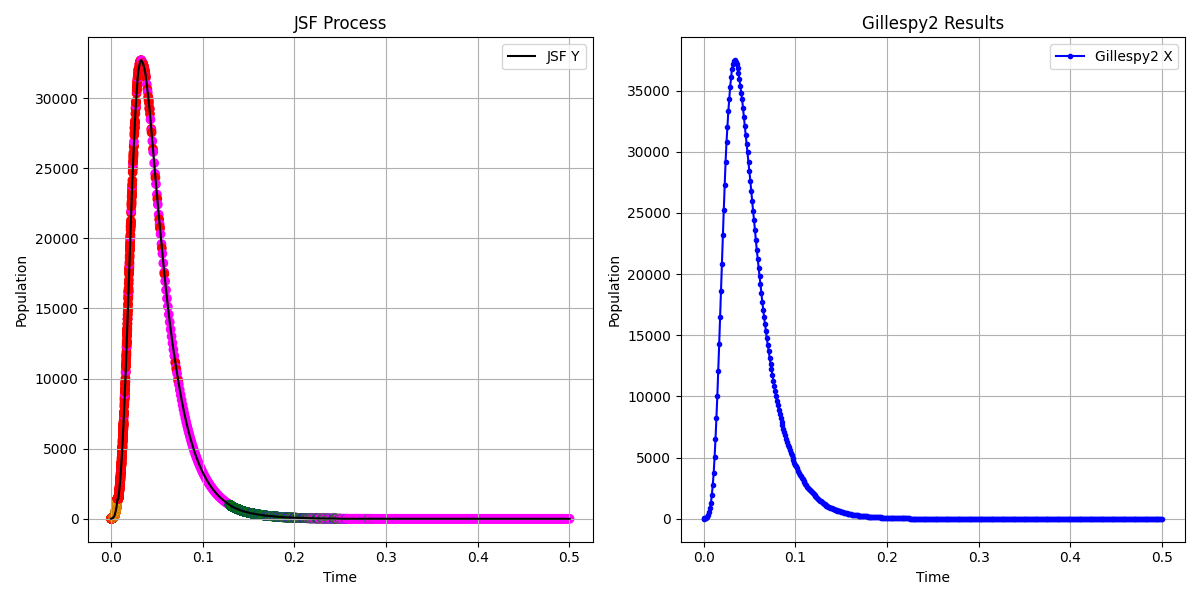

In [5]:

# create an array that contains all the points where the indicator function is 1
# and the corresponding time points for the JSF process

print("proportion of time spent in the discrete state: ", np.sum(ind_sim_jsf[2]) / len(ind_sim_jsf[2]))
Ind = ind_sim_jsf[2]  # Example indicator function
# Generate a vector of colors based on the indicator function
colors = []
for val in Ind[:len(ind_sim_jsf[1])]:
    if val == -1:
        colors.append('magenta')
    elif val == 0:
        colors.append('blue')
    elif val == 1:
        colors.append('green')
    elif val == 2:
        colors.append('orange')
    elif val == 3:
        colors.append('red')
    else:
        colors.append('black')

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot JSF process
ax[0].plot(ind_sim_jsf[1], ind_sim_jsf[0][0], 'k-', label='JSF Y')
ax[0].scatter(ind_sim_jsf[1], ind_sim_jsf[0][0], c=colors)
ax[0].set_title('JSF Process')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Population')
ax[0].grid()
ax[0].legend()

# Plot ind_results_gp2
ax[1].plot(ind_results_gp2[0]['time'], ind_results_gp2[0]['X'], 'b.-', label='Gillespy2 X')
# ax[1].plot(ind_results_gp2[0]['time'], ind_results_gp2[0]['Y'], 'r-', label='Gillespy2 Y')
ax[1].set_title('Gillespy2 Results')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Population')
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()



<>:65: SyntaxWarning: invalid escape sequence '\O'
<>:73: SyntaxWarning: invalid escape sequence '\O'
<>:65: SyntaxWarning: invalid escape sequence '\O'
<>:73: SyntaxWarning: invalid escape sequence '\O'
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/2464817945.py:65: SyntaxWarning: invalid escape sequence '\O'
  ax[0, 1].set_title('JSF: $\Omega = 10^3$')
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/2464817945.py:73: SyntaxWarning: invalid escape sequence '\O'
  ax[1, 1].set_title('JSF: $\Omega = 10^3$')
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/2464817945.py:6: RuntimeWarning: divide by zero encountered in log
  max_values_gp2 = [np.max(np.log(traj[0])) for traj in results_gp2_interp]
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/2464817945.py:7: RuntimeWarning: divide by zero encountered in log
  max_values_jsf = [np.max(np.log(traj[0])) for traj in results_jsf_interp]
/var/folders/w6/dtzmmv853z34h6pgfd8g

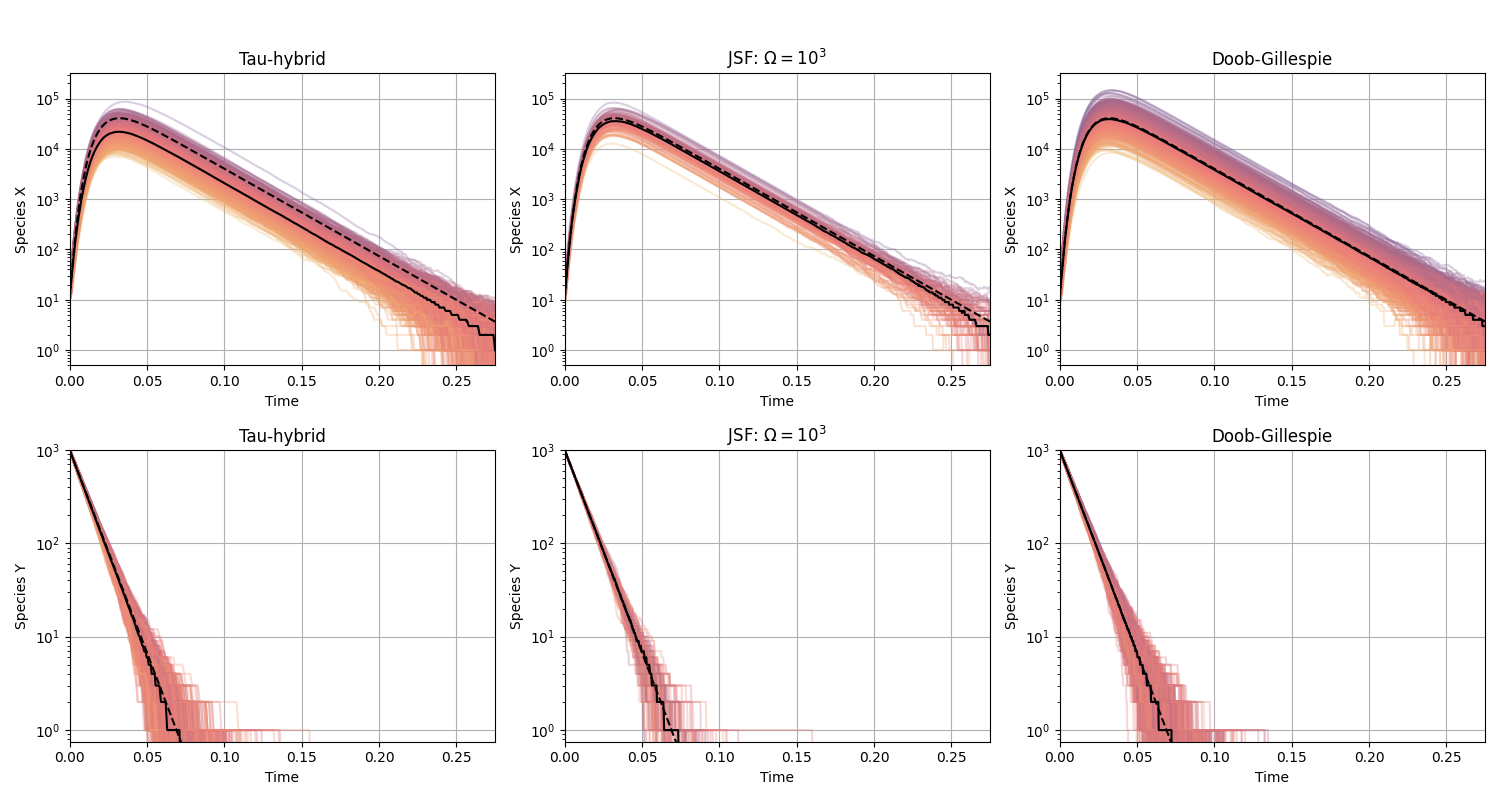

In [106]:
from matplotlib.colors import LinearSegmentedColormap

alpha_val = 0.3

# Determine the color based on the maximum value of each trajectory
max_values_gp2 = [np.max(np.log(traj[0])) for traj in results_gp2_interp]
max_values_jsf = [np.max(np.log(traj[0])) for traj in results_jsf_interp]
max_values_generous_jsf = [np.max(np.log(traj[0])) for traj in results_generous_jsf_interp]
max_vales_gil = [np.max(np.log(traj[0])) for traj in results_gil_interp]

# Normalize the maximum values to the range [0, 1] for color mapping
norm_gp2 = plt.Normalize(min(max_values_gp2), max(max_values_gp2))
norm_jsf = plt.Normalize(min(max_values_jsf), max(max_values_jsf))
norm_generous_jsf = plt.Normalize(min(max_values_generous_jsf), max(max_values_generous_jsf))
norm_gil = plt.Normalize(min(max_vales_gil), max(max_vales_gil))

# Create a color map
# Define the color gradient
jsf_color = (131/255, 96/255, 150/255)
gp2_color = (237/255, 123/255, 123/255)
gil_color = (240/255, 184/255, 110/255)
colors = [gil_color, gp2_color, jsf_color]
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
# Plot the results
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# Plot Gillespy2 results
for idx, traj in enumerate(results_gp2_interp):
    color_gp2 = cmap(norm_gp2(max_values_gp2[idx]))
    ax[0, 0].plot(t_common, traj[0], color=color_gp2, alpha=alpha_val)
    ax[1, 0].plot(t_common, traj[1], color=color_gp2, alpha=alpha_val)

ax[0, 0].plot(t_common, mean_gp2[0], 'k-', label='Mean')
ax[1, 0].plot(t_common, mean_gp2[1], 'k-', label='Mean')
ax[0, 0].plot(results_ode['time'], results_ode['X'], 'k--', label='Analytic')
ax[1, 0].plot(results_ode['time'], results_ode['Y'], 'k--', label='Analytic')

ax[0, 0].set_title('Tau-hybrid')
ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Species X')
ax[0, 0].set_yscale('log')
ax[0, 0].grid()
ax[0, 0].set_ylim(0.5, 10**5.5)
ax[0, 0].set_xlim(0, t_max)

ax[1, 0].set_title('Tau-hybrid')
ax[1, 0].set_xlabel('Time')
ax[1, 0].set_ylabel('Species Y')
ax[1, 0].set_yscale('log')
ax[1, 0].grid()
ax[1, 0].set_ylim(0.75, 10**3)
ax[1, 0].set_xlim(0, t_max)

# Plot JSF results
for idx, sim_jsf in enumerate(results_jsf_interp):
    color_jsf = cmap(norm_jsf(max_values_jsf[idx]))
    ax[0, 1].plot(t_common, sim_jsf[0], color=color_jsf, alpha=alpha_val)
    ax[1, 1].plot(t_common, sim_jsf[1], color=color_jsf, alpha=alpha_val)

ax[0, 1].plot(t_common, mean_jsf[0], 'k-', label='Mean')
ax[1, 1].plot(t_common, mean_jsf[1], 'k-', label='Mean')
ax[0, 1].plot(results_ode['time'], results_ode['X'], 'k--', label='Analytic')
ax[1, 1].plot(results_ode['time'], results_ode['Y'], 'k--', label='Analytic')

ax[0, 1].set_title('JSF: $\Omega = 10^3$')
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('Species X')
ax[0, 1].set_yscale('log')
ax[0, 1].grid()
ax[0, 1].set_ylim(0.5, 10**5.5)
ax[0, 1].set_xlim(0, t_max)

ax[1, 1].set_title('JSF: $\Omega = 10^3$')
ax[1, 1].set_xlabel('Time')
ax[1, 1].set_ylabel('Species Y')
ax[1, 1].set_yscale('log')
ax[1, 1].grid()
ax[1, 1].set_ylim(0.75, 10**3)
ax[1, 1].set_xlim(0, t_max)

# Plot SSA results
for idx, traj in enumerate(results_gil_interp):
    color_gil = cmap(norm_gil(max_vales_gil[idx]))
    ax[0, 2].plot(t_common, traj[0], color=color_gil, alpha=alpha_val)
    ax[1, 2].plot(t_common, traj[1], color=color_gil, alpha=alpha_val)

ax[0, 2].plot(t_common, mean_gil[0], 'k-', label='Mean')
ax[1, 2].plot(t_common, mean_gil[1], 'k-', label='Mean')
ax[0, 2].plot(results_ode['time'], results_ode['X'], 'k--', label='Analytic')
ax[1, 2].plot(results_ode['time'], results_ode['Y'], 'k--', label='Analytic')

ax[0, 2].set_title('Doob-Gillespie')
ax[0, 2].set_xlabel('Time')
ax[0, 2].set_ylabel('Species X')
ax[0, 2].set_yscale('log')
ax[0, 2].grid()
ax[0, 2].set_ylim(0.5, 10**5.5)
ax[0, 2].set_xlim(0, t_max)

ax[1, 2].set_title('Doob-Gillespie')
ax[1, 2].set_xlabel('Time')
ax[1, 2].set_ylabel('Species Y')
ax[1, 2].set_yscale('log')
ax[1, 2].grid()
ax[1, 2].set_ylim(0.75, 10**3)
ax[1, 2].set_xlim(0, t_max)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# plt.savefig('AutocatalystTrajectores.pdf')

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:43: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:43: SyntaxWarning: invalid escape sequence '\O'
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/2210409700.py:5: SyntaxWarning: invalid escape sequence '\O'
  labels = ['Tau-Hybrid', 'JSF: $\Omega = 10^3$', 'Doob-Gillespie']
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_69510/2210409700.py:43: SyntaxWarning: invalid escape sequence '\O'
  ax[2].plot(t_common, error_jsf_X, '-', label='JSF: $\Omega=10^3$', color=jsf_color, linewidth=lnwdth)


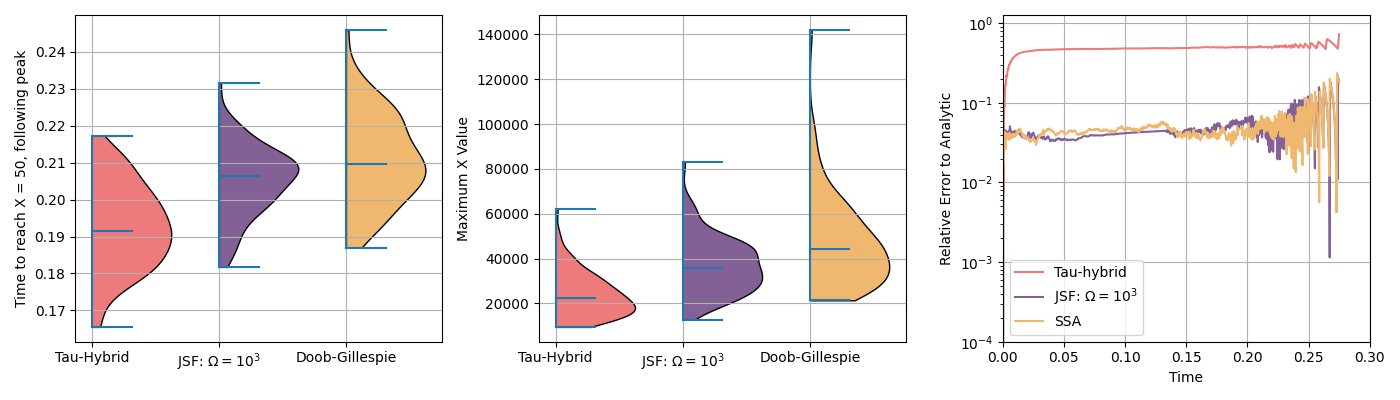

In [105]:
jsf_color = (131/255, 96/255, 150/255)
gp2_color = (237/255, 123/255, 123/255)
gil_color = (240/255, 184/255, 110/255)

labels = ['Tau-Hybrid', 'JSF: $\Omega = 10^3$', 'Doob-Gillespie']

# plot the results
lnwdth = 1.5
# create a subplot to plot the hitting time and max X value using violin plots
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# Hitting time violin plot
parts =  ax[0].violinplot([time_to_reach_gp2, time_to_reach_jsf, time_to_reach_gil], showextrema=True, showmedians=True, side='high', widths=1.25)
colors = [gp2_color, jsf_color, gil_color]
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(1)

ax[0].set_xticks([1, 2, 3])
# ax[0].set_xticklabels(labels, fontsize=12, rotation=-45, ha='left')
ax[0].set_xticklabels(labels)
ax[0].set_ylabel('Time to reach X = 50, following peak')
# ax[0].set_title('Hitting Time')
ax[0].grid()

# Max X value violin plot
parts =  ax[1].violinplot([max_x_gp2, max_x_jsf, max_x_gil], showextrema=True, showmedians=True, side='high', widths=1.25)
colors = [gp2_color, jsf_color, gil_color]
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(1)
    
ax[1].set_xticks([1, 2, 3])
# ax[1].set_xticklabels(labels, fontsize=12, rotation=-45, ha='left')
ax[1].set_xticklabels(labels)
ax[1].set_ylabel('Maximum X Value')
# ax[1].set_title('Maximum X Value')
ax[1].grid()

ax[2].plot(t_common, error_gp2_X, '-', label='Tau-hybrid', color=gp2_color, linewidth=lnwdth)
ax[2].plot(t_common, error_jsf_X, '-', label='JSF: $\Omega=10^3$', color=jsf_color, linewidth=lnwdth)
ax[2].plot(t_common, error_gil_X, '-', label='SSA', color=gil_color, linewidth=lnwdth)
ax[2].set_xlabel('Time')
ax[2].set_ylabel('Relative Error to Analytic')
ax[2].set_yscale('log')
ax[2].set_ylim(pow(10,-4), pow(10,0.1))
ax[2].set_xlim(0, 0.3)
ax[2].grid()
ax[2].legend()

plt.tight_layout()
plt.show()

plt.savefig('AutocatalystSummaryData.pdf')